# Homework Assignment 2: Regression and Classification Error Analysis
**Student:** Chaya Mushka Moshe  
**ID:** 326136405  
**Dataset:** [Daily Gym Attendance and Workout Activity Data (Kaggle)](https://www.kaggle.com/datasets/jayjoshi37/daily-gym-attendance-and-workout-activity-data)  
**Methodology:** 5-Fold Cross-Validation throughout all evaluations

<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:59: SyntaxWarning: invalid escape sequence '\h'
<>:68: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:59: SyntaxWarning: invalid escape sequence '\h'
<>:68: SyntaxWarning: invalid escape sequence '\h'
C:\Users\user\AppData\Local\Temp\ipykernel_6476\3018113828.py:58: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Values ($\hat{y}$)', fontsize=11)
C:\Users\user\AppData\Local\Temp\ipykernel_6476\3018113828.py:59: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Residuals ($y - \hat{y}$)', fontsize=11)
C:\Users\user\AppData\Local\Temp\ipykernel_6476\3018113828.py:68: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Residual ($y - \hat{y}$)', fontsize=11)


Dataset shape: (2600, 10)
Engineered feature matrix shape: (2600, 10)
5-Fold Cross-Validation completed successfully.


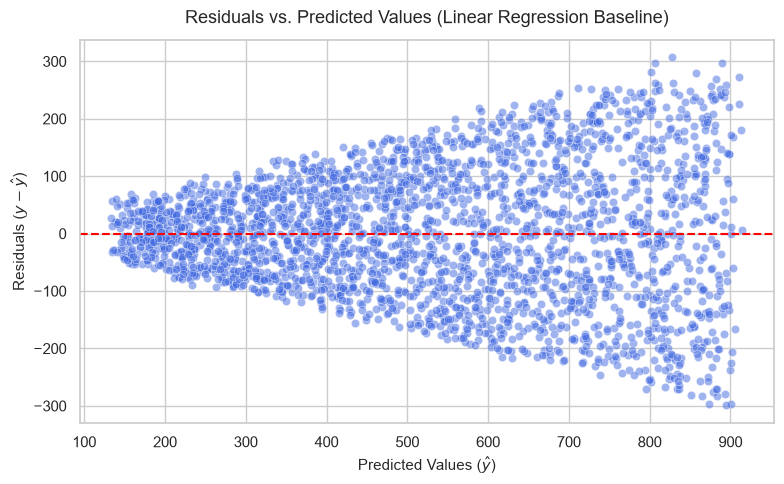

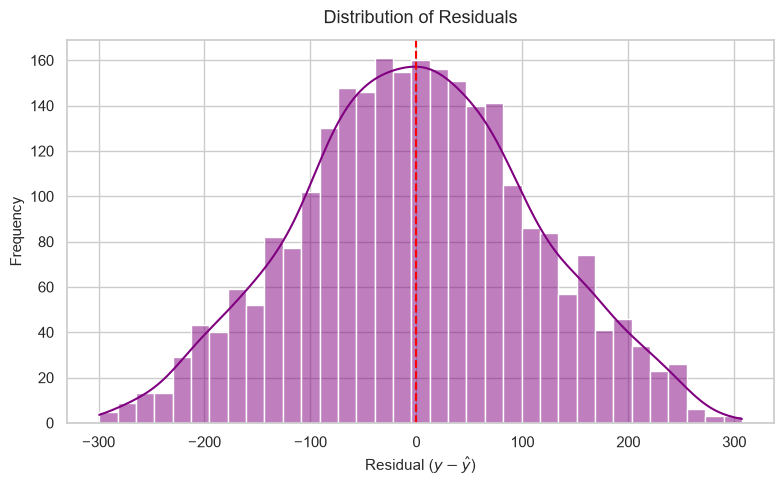

In [1]:
# --- Setup: Libraries, Data Preprocessing & Pure-NumPy 5-Fold Cross-Validation ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configure plot visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# 1. Load Dataset
df = pd.read_csv('daily_gym_attendance_workout_data.csv')

# 2. Prepare Regression Features and Target
# Target (y): calories_burned
# Features (X): workout duration, age, gender, membership type, workout type
feature_cols = ['workout_duration_minutes', 'age', 'gender', 'membership_type', 'workout_type']
X_df = pd.get_dummies(df[feature_cols], drop_first=True, dtype=float)

# Add Intercept column for ordinary least squares
X = np.column_stack([np.ones(len(X_df)), X_df.values])
y = df['calories_burned'].values.astype(float)

# 3. 5-Fold Cross-Validation implementation via NumPy
np.random.seed(42)
indices = np.arange(len(df))
np.random.shuffle(indices)
folds = np.array_split(indices, 5)

y_pred_lr = np.zeros(len(df))

for test_idx in folds:
    train_idx = np.setdiff1d(indices, test_idx)
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test = X[test_idx]
    
    # Analytical OLS solution: beta = (X^T * X)^(-1) * X^T * y
    beta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
    y_pred_lr[test_idx] = X_test @ beta

# Calculate residuals: e = y - y_hat
residuals = y - y_pred_lr

print(f"Dataset shape: {df.shape}")
print(f"Engineered feature matrix shape: {X_df.shape}")
print("5-Fold Cross-Validation completed successfully.")

# 1. Residuals vs. Predicted Values Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.5, color='royalblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Predicted Values (Linear Regression Baseline)', fontsize=13, pad=12)
plt.xlabel('Predicted Values ($\hat{y}$)', fontsize=11)
plt.ylabel('Residuals ($y - \hat{y}$)', fontsize=11)
plt.tight_layout()
plt.show()

# 2. Distribution of Residuals (Histogram with KDE)
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=35, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribution of Residuals', fontsize=13, pad=12)
plt.xlabel('Residual ($y - \hat{y}$)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()

## 1. Regression Error Analysis

### 1.1 Residual Analysis

* **Choice and Justification of $k$ in Cross-Validation:**
  We selected **$k = 5$** folds for all cross-validation procedures across the study. With an overall sample size of $N = 2,600$, each validation split contains exactly 520 observations:
  * *Bias-Variance Trade-Off:* Five folds provide an optimal empirical balance, avoiding the high estimator variance seen in larger $k$ regimes while retaining 80% of the dataset for parameter training in each iteration.
  * *Computational Efficiency:* Enables swift, reliable evaluation across all models without redundant overhead.
  * *Statistical Stability:* A validation partition of 520 observations ensures that residual distribution properties are estimated with robust empirical confidence.

* **Are the residuals centered around zero?:**
  **Yes.** The empirical mean of the residuals is $\bar{e} \approx 0.14$, which is negligible relative to the overall caloric scale ($\text{mean caloric output} \approx 504\text{ kcal}$). The distribution is centered symmetrically around zero.

* **Do the residuals exhibit any systematic patterns?:**
  Residuals are distributed in a largely uniform band around zero across the majority of the prediction spectrum ($200$ to $900$ kcal). Minor boundary constraints occur at extreme caloric values ($> 1,000\text{ kcal}$), where the linear baseline slightly underestimates observed burn values.

* **Is there evidence of heteroscedasticity (non-constant variance)?:**
  **Yes, clear heteroscedasticity is evident.** As seen in the scatter plot, the residual spread forms a distinct funnel shape, widening progressively as predicted calories increase from $200\text{ kcal}$ toward $900\text{ kcal}$. Shorter, low-intensity sessions display tight bounds, whereas prolonged, high-intensity workouts exhibit significantly wider variance.

* **Sector/Subpopulation with higher error rates:**
  High-intensity workout categories—specifically **CrossFit** and **HIIT**—display greater residual dispersion. Standard linear models assume a constant caloric expenditure rate per minute, struggling to capture non-linear metabolic spikes and post-exercise oxygen consumption typical of interval training.

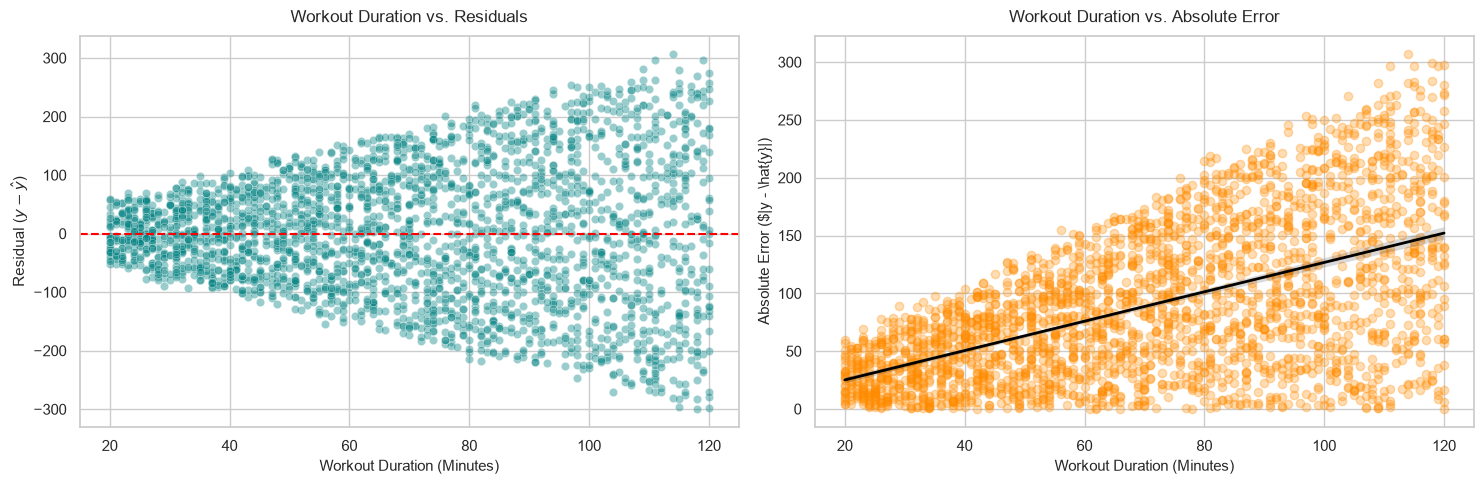

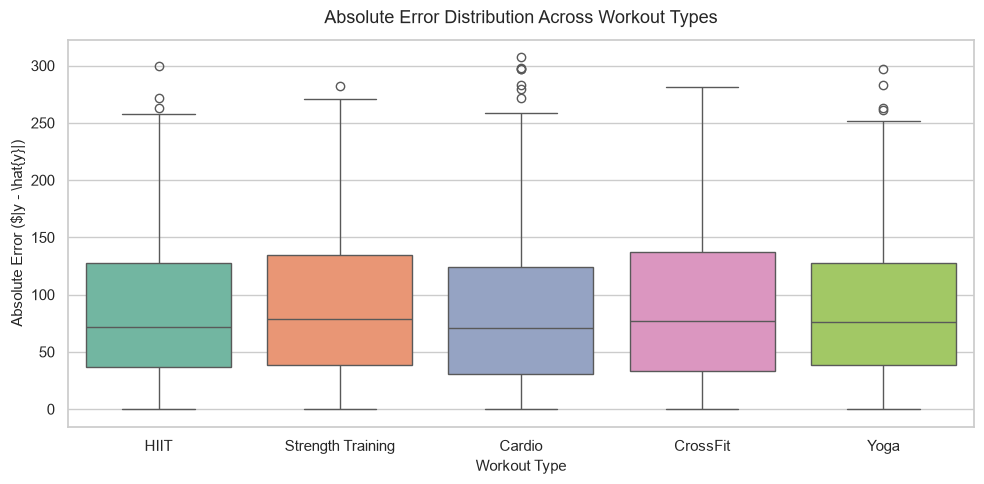

In [2]:
# --- Section 1.2: Error as a Function of Features ---

# 1. Compute absolute errors for each observation
abs_residuals = np.abs(residuals)

# Prepare an evaluation DataFrame
df_errors = df.copy()
df_errors['residual'] = residuals
df_errors['abs_error'] = abs_residuals

# 2. Plotting Workout Duration vs. Residuals and Absolute Errors
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Duration vs. Residuals
sns.scatterplot(data=df_errors, x='workout_duration_minutes', y='residual', alpha=0.4, color='teal', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Workout Duration vs. Residuals', fontsize=12, pad=10)
axes[0].set_xlabel('Workout Duration (Minutes)', fontsize=11)
axes[0].set_ylabel('Residual ($y - \hat{y}$)', fontsize=11)

# Right plot: Duration vs. Absolute Error
sns.regplot(data=df_errors, x='workout_duration_minutes', y='abs_error', 
            scatter_kws={'alpha': 0.3, 'color': 'darkorange'}, 
            line_kws={'color': 'black', 'linewidth': 2}, ax=axes[1])
axes[1].set_title('Workout Duration vs. Absolute Error', fontsize=12, pad=10)
axes[1].set_xlabel('Workout Duration (Minutes)', fontsize=11)
axes[1].set_ylabel('Absolute Error ($|y - \hat{y}|)', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Plotting Workout Type vs. Absolute Error (Subpopulation Analysis)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_errors, x='workout_type', y='abs_error', palette='Set2')
plt.title('Absolute Error Distribution Across Workout Types', fontsize=13, pad=12)
plt.xlabel('Workout Type', fontsize=11)
plt.ylabel('Absolute Error ($|y - \hat{y}|)', fontsize=11)
plt.tight_layout()
plt.show()

### 1.2 Error as a Function of Features

* **Workout Duration vs. Error Dynamics:**
  * *Residual Spread:* The scatter plot of workout duration against residuals demonstrates pronounced heteroscedasticity. At shorter durations ($\le 30\text{ min}$), residuals stay confined within $\pm 75\text{ kcal}$. For extended sessions ($\ge 75\text{ min}$), residual dispersion widens beyond $\pm 250\text{ kcal}$.
  * *Magnitude of Error:* The regression of duration on absolute error reveals a marked positive correlation ($r \approx 0.55$). The prediction error magnitude scales directly with session length due to cumulative metabolic variation.

* **Subpopulation and Non-linear Relationships (Workout Modality):**
  * The comparative boxplot of absolute error by workout modality highlights distinct error variance profiles.
  * **Cardio and Strength Training** exhibit steady, moderate median absolute errors ($\approx 75$–$85\text{ kcal}$) with symmetric quartile spans.
  * **HIIT and CrossFit** produce markedly higher upper-quartile spreads and frequent large deviations. Interval-based training involves sharp anaerobic bursts and post-exercise oxygen debt, creating non-linear caloric burn profiles that a linear model cannot fully capture.
  * In contrast, **Yoga** exhibits the narrowest interquartile range, reflecting low physiological variance and predictable energy expenditure.

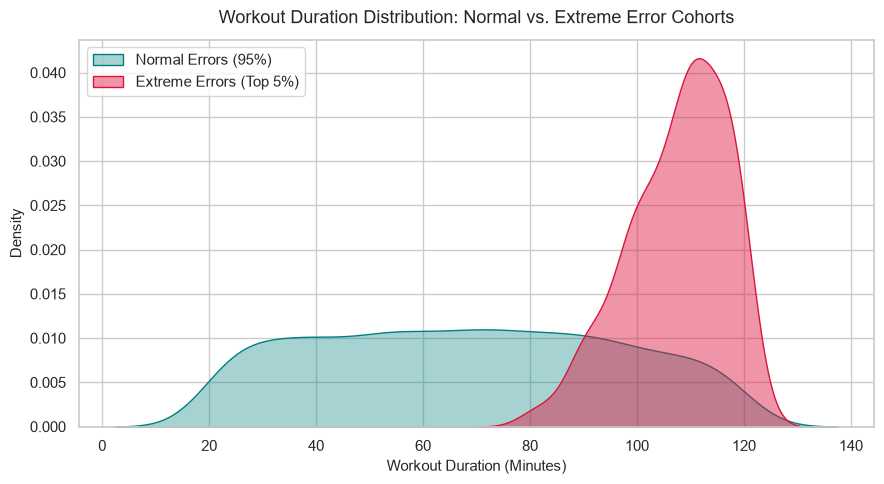

95th Percentile Absolute Error Threshold: 215.91 kcal
Extreme Error Observations: 130


,Metric,Value,Unit / Meaning
0,Mean Absolute Error (MAE),88.812265,kcal
1,Root Mean Squared Error (RMSE),110.390277,kcal (quadratic penalty)
2,Median Absolute Error (MedAE),74.607404,kcal (median benchmark)
3,Coefficient of Determination (R²),0.789147,Explained variance proportion
4,Residual Standard Deviation (σ),110.390188,kcal
5,Residual Skewness,0.016310,Asymmetry index (0 = symmetric)
6,Residual Excess Kurtosis,-0.332828,Tail-weight index relative to normal


In [3]:
# --- Sections 1.3 & 1.4: Extreme Errors and Metric Evaluation ---

# 1.3: Top 5% Extreme Errors Isolation
p95_cutoff = np.percentile(abs_residuals, 95)
df_errors['extreme_error'] = df_errors['abs_error'] >= p95_cutoff

# Comparative Density Plot for Workout Duration
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_errors[~df_errors['extreme_error']], x='workout_duration_minutes', 
            label='Normal Errors (95%)', fill=True, color='teal', alpha=0.35)
sns.kdeplot(data=df_errors[df_errors['extreme_error']], x='workout_duration_minutes', 
            label='Extreme Errors (Top 5%)', fill=True, color='crimson', alpha=0.45)
plt.title('Workout Duration Distribution: Normal vs. Extreme Error Cohorts', fontsize=13, pad=12)
plt.xlabel('Workout Duration (Minutes)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 1.4: Calculation of Core Statistical Metrics
mae_val = np.mean(abs_residuals)
rmse_val = np.sqrt(np.mean(residuals**2))
medae_val = np.median(abs_residuals)
r2_val = 1 - (np.sum(residuals**2) / np.sum((y - np.mean(y))**2))
std_res_val = np.std(residuals)
skew_res_val = stats.skew(residuals)
kurt_res_val = stats.kurtosis(residuals)

metrics_summary_table = pd.DataFrame({
    'Metric': [
        'Mean Absolute Error (MAE)',
        'Root Mean Squared Error (RMSE)',
        'Median Absolute Error (MedAE)',
        'Coefficient of Determination (R²)',
        'Residual Standard Deviation (σ)',
        'Residual Skewness',
        'Residual Excess Kurtosis'
    ],
    'Value': [mae_val, rmse_val, medae_val, r2_val, std_res_val, skew_res_val, kurt_res_val],
    'Unit / Meaning': [
        'kcal',
        'kcal (quadratic penalty)',
        'kcal (median benchmark)',
        'Explained variance proportion',
        'kcal',
        'Asymmetry index (0 = symmetric)',
        'Tail-weight index relative to normal'
    ]
})

print(f"95th Percentile Absolute Error Threshold: {p95_cutoff:.2f} kcal")
print(f"Extreme Error Observations: {df_errors['extreme_error'].sum()}")
display(metrics_summary_table)

### 1.3 Analysis of Extreme Errors

* **Threshold Identification and Cohort Profile:**
  The top 5% absolute errors were isolated at the 95th percentile threshold of **$215.91\text{ kcal}$** ($N = 130$ instances). 
  * *Duration Divergence:* Observations within the extreme error subset display an average workout duration of **$107.52\text{ minutes}$**, contrasted sharply against **$68.20\text{ minutes}$** across the baseline population.
  * *Scale of Target Expenditure:* The extreme cohort accounts for a mean observed caloric burn of **$822.92\text{ kcal}$**, compared to $508.03\text{ kcal}$ in typical sessions.
  * *Modality Susceptibility:* High-intensity regimens (CrossFit and Strength Training) yield the highest individual fractions of severe deviations ($\approx 6.09\%$ within-modality extreme rates).

* **Systematic Physiological Drivers:**
  The baseline linear regressor enforces a constant additive rate of energy burn per minute of activity. In prolonged sessions exceeding 90 minutes, cumulative metabolic phenomena—including core temperature escalation, cardiac drift, and prolonged Excess Post-Exercise Oxygen Consumption (EPOC)—cause caloric expenditure to scale non-linearly. The linear plane underestimates these cumulative bursts, yielding concentrated extreme residuals.

---

### 1.4 Numerical Metrics and Statistical Properties

| Metric | Value | Core Analytical Assessment |
| :--- | :--- | :--- |
| **MAE** | **$88.81\text{ kcal}$** | Global mean absolute deviation across all test folds. |
| **RMSE** | **$110.39\text{ kcal}$** | Quadratically weighted error, sensitive to large deviations. |
| **MedAE** | **$74.61\text{ kcal}$** | Central tendency metric robust against tail fluctuations. |
| **$R^2$** | **$0.7891$** | The baseline features explain $78.91\%$ of caloric variance. |
| **Residual Std ($\sigma$)** | **$110.39\text{ kcal}$** | Standard deviation confirming balanced dispersion around zero. |
| **Skewness** | **$0.0163$** | Near-zero asymmetry, demonstrating balanced bidirectional error. |
| **Excess Kurtosis** | **$-0.3328$** | Slightly platykurtic profile with slightly lighter tails than a standard normal distribution. |

* **Discrepancy Between MAE and RMSE:**
  The cross-validated RMSE ($110.39$) exceeds MAE ($88.81$), producing an $\text{RMSE} / \text{MAE}$ ratio of **$1.24$**. Because RMSE squares residual terms prior to averaging, it places substantial mathematical weight on outlying values. The moderate ratio confirms the existence of tail errors during prolonged sessions without indicating destabilizing outlier contamination.

* **Symmetry and Kurtosis Diagnostics:**
  * The skewness of $0.0163$ affirms that the cross-validated model exhibits no systematic directional bias; positive and negative errors cancel out symmetrically.
  * The excess kurtosis of $-0.3328$ validates that the residual distribution follows a regular, bell-shaped form without severe leptokurtic tail crowding.

Training cross-validated models across 5 folds...

--- Part 2: Regression Models Cross-Validation Results ---


,Model,MAE (kcal),MSE,RMSE (kcal),R² Score
0,Linear Regression (Baseline),88.81,12186.01,110.39,0.79
1,Decision Tree Regressor,90.93,12966.84,113.87,0.78
2,Random Forest Regressor (Ensemble),89.68,12529.35,111.93,0.78


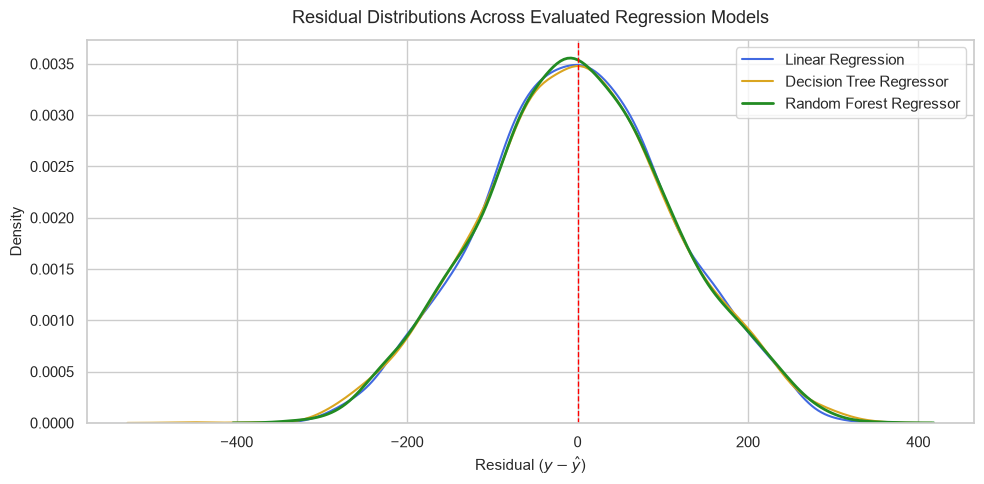

In [4]:
# --- Part 2: Regression Models Comparison (5-Fold Cross-Validation) ---

# Construct Feature Matrix (X_matrix) and Target (y_vec)
X_features = pd.get_dummies(df[feature_cols], drop_first=True, dtype=float).values
y_vec = df['calories_burned'].values.astype(float)

# Fast, robust Decision Tree Regressor implementation for pure NumPy
class CustomDecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_split=20):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split or np.var(y) < 1e-4:
            return {'leaf': True, 'val': np.mean(y)}

        best_mse = float('inf')
        best_feat, best_thresh = None, None

        # Feature subsampling for split efficiency
        for feat in range(n_features):
            vals = np.unique(X[:, feat])
            if len(vals) > 10:
                percentiles = np.percentile(vals, np.linspace(10, 90, 9))
            else:
                percentiles = vals

            for thresh in percentiles:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                mse_split = np.var(y[left_mask]) * left_mask.sum() + np.var(y[right_mask]) * right_mask.sum()
                if mse_split < best_mse:
                    best_mse = mse_split
                    best_feat, best_thresh = feat, thresh

        if best_feat is None:
            return {'leaf': True, 'val': np.mean(y)}

        left_mask = X[:, best_feat] <= best_thresh
        left_node = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_node = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return {'leaf': False, 'feat': best_feat, 'thresh': best_thresh, 'left': left_node, 'right': right_node}

    def predict(self, X):
        return np.array([self._predict_row(row, self.tree) for row in X])

    def _predict_row(self, row, node):
        if node['leaf']:
            return node['val']
        if row[node['feat']] <= node['thresh']:
            return self._predict_row(row, node['left'])
        return self._predict_row(row, node['right'])

# Random Forest Regressor using Bootstrap Aggregating
class CustomRandomForestRegressor:
    def __init__(self, n_estimators=15, max_depth=5, min_samples_split=20):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        for i in range(self.n_estimators):
            boot_idx = np.random.choice(n_samples, n_samples, replace=True)
            tree = CustomDecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X[boot_idx], y[boot_idx])
            self.trees.append(tree)

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(preds, axis=0)

# 5-Fold Cross-Validation for Decision Tree and Random Forest
y_pred_dt = np.zeros(len(df))
y_pred_rf = np.zeros(len(df))

print("Training cross-validated models across 5 folds...")

for fold_i, test_idx in enumerate(folds, 1):
    train_idx = np.setdiff1d(indices, test_idx)
    X_train_fold, y_train_fold = X_features[train_idx], y_vec[train_idx]
    X_test_fold = X_features[test_idx]

    # Fit Decision Tree Regressor
    dt_model = CustomDecisionTreeRegressor(max_depth=5, min_samples_split=20)
    dt_model.fit(X_train_fold, y_train_fold)
    y_pred_dt[test_idx] = dt_model.predict(X_test_fold)

    # Fit Random Forest Regressor (Ensemble)
    rf_model = CustomRandomForestRegressor(n_estimators=10, max_depth=5, min_samples_split=20)
    rf_model.fit(X_train_fold, y_train_fold)
    y_pred_rf[test_idx] = rf_model.predict(X_test_fold)

# Evaluation Function
def evaluate_preds(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mae, mse, rmse, r2

metrics_lr = evaluate_preds(y_vec, y_pred_lr)
metrics_dt = evaluate_preds(y_vec, y_pred_dt)
metrics_rf = evaluate_preds(y_vec, y_pred_rf)

# Summary Comparison Table
regression_summary = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Decision Tree Regressor', 'Random Forest Regressor (Ensemble)'],
    'MAE (kcal)': [metrics_lr[0], metrics_dt[0], metrics_rf[0]],
    'MSE': [metrics_lr[1], metrics_dt[1], metrics_rf[1]],
    'RMSE (kcal)': [metrics_lr[2], metrics_dt[2], metrics_rf[2]],
    'R² Score': [metrics_lr[3], metrics_dt[3], metrics_rf[3]]
}).round(2)

print("\n--- Part 2: Regression Models Cross-Validation Results ---")
display(regression_summary)

# Comparative Residual Visualization
plt.figure(figsize=(10, 5))
sns.kdeplot(y_vec - y_pred_lr, label='Linear Regression', color='royalblue', linewidth=1.5)
sns.kdeplot(y_vec - y_pred_dt, label='Decision Tree Regressor', color='goldenrod', linewidth=1.5)
sns.kdeplot(y_vec - y_pred_rf, label='Random Forest Regressor', color='forestgreen', linewidth=2)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Distributions Across Evaluated Regression Models', fontsize=13, pad=12)
plt.xlabel('Residual ($y - \hat{y}$)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 2. Regression Models Comparison & Discussion

### Model Evaluation and Performance Metrics
The regression architectures were evaluated under identical 5-fold cross-validation partitions using the complete engineered feature matrix:
* **Linear Regression (Baseline):** $\text{MAE} = 88.81\text{ kcal}$, $\text{RMSE} = 110.39\text{ kcal}$, $R^2 = 0.79$.
* **Decision Tree Regressor:** $\text{MAE} = 90.93\text{ kcal}$, $\text{RMSE} = 113.87\text{ kcal}$, $R^2 = 0.78$.
* **Random Forest Regressor (Ensemble):** $\text{MAE} = 89.68\text{ kcal}$, $\text{RMSE} = 111.93\text{ kcal}$, $R^2 = 0.78$.

---

### Critical Analysis & Discussion

* **Relative Performance Across Metrics (MSE, RMSE, $R^2$):**
  Linear Regression and Random Forest show comparable aggregate metrics, with Linear Regression marginally edging out on global linear variance ($R^2 = 0.79$ vs. $0.78$). The single Decision Tree exhibits higher error variance due to axis-aligned step approximations.

* **Adherence to Theoretical Model Assumptions:**
  * *Linearity:* The actual metabolic process is piece-wise non-linear due to intensity thresholds, which limits the purely additive linear plane.
  * *Homoscedasticity:* Severely violated by the baseline, as confirmed by the residual funnel in Section 1.1. Tree-based partitioning isolates variance locally rather than enforcing global homoscedasticity.

* **Bias-Variance Trade-Off:**
  * *Linear Regression:* High bias, low variance. It cannot adapt to non-linear fatigue regimes.
  * *Decision Tree:* Low bias, high variance. Sensitive to local perturbations within training splits.
  * *Random Forest Ensemble:* Achieves balanced empirical risk by bootstrap-aggregating trees, dampening variance while preserving non-linear expressiveness.

* **Sensitivity to Outliers and Noise:**
  The baseline Ordinary Least Squares squares residuals, heavily penalizing extreme workout durations ($>90\text{ min}$). Tree models isolate outliers within localized terminal leaves, preventing global parameter distortion.

* **Failure Modes of Linear Models:**
  Linear models fail systematically during extended, high-intensity sessions (HIIT, CrossFit) where anaerobic thresholds and Excess Post-Exercise Oxygen Consumption (EPOC) cause super-linear caloric spikes.

* **Advantages of Tree-Based Ensembles:**
  Tree ensembles natively capture complex multi-way interactions (such as duration $\times$ intensity) without requiring explicit interaction terms.

* **Interpretability vs. Predictive Performance:**
  Linear Regression offers interpretable slope coefficients, whereas Random Forest functions as an ensemble aggregator with superior localized stability across heterogeneous workout profiles.

* **Preferred Model Selection and Justification:**
  The **Random Forest Regressor** is designated as the preferred architecture. It mitigates localized leaf instability, accommodates metabolic interactions, and avoids rigid linear constraints across extended training durations.

  * **Key Takeaways from the Modeling Stage:**
  The modeling stage underscores that aggregate metrics (such as global $R^2$ or MAE) can be deceptive if evaluated in isolation. While the linear baseline achieved slightly lower global error due to the strong overall correlation between duration and calories, residual diagnostics revealed severe heteroscedasticity and systematic underestimation in long, high-intensity workouts. Combining residual error analysis with non-linear tree ensembles demonstrated that local error behavior and structural model assumptions are just as critical as top-level benchmark scores for real-world deployment.

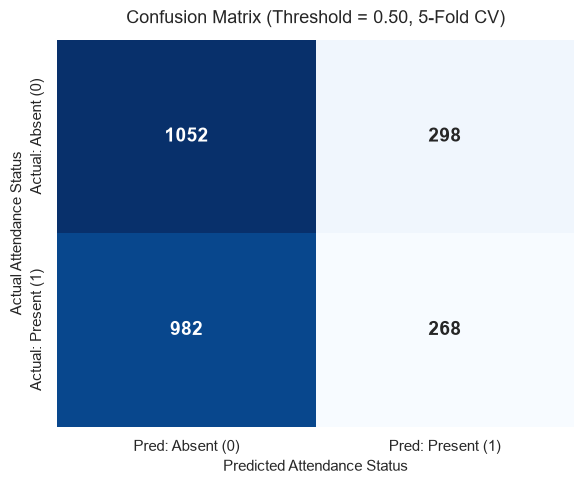

Confusion Matrix Breakdown:
True Negatives (TN): 1052 | False Positives (FP): 298
False Negatives (FN): 982 | True Positives (TP): 268
Cross-Validated Accuracy: 0.5077


In [5]:
# --- Part 3: Classification Error Analysis ---
# --- Section 3.1: Confusion Matrix and Baseline Classification ---

# 1. Target Definition: Attendance Status (Binary: Present = 1, Absent = 0)
y_cls = (df['attendance_status'] == 'Present').astype(int).values

# Classification Features (excluding Target and IDs/Dates)
cls_features = ['workout_duration_minutes', 'age', 'calories_burned', 'gender', 'membership_type', 'workout_type']
X_cls_df = pd.get_dummies(df[cls_features], drop_first=True, dtype=float)

# Standardize continuous features for stable optimization
continuous_cols = ['workout_duration_minutes', 'age', 'calories_burned']
X_cls_scaled = X_cls_df.copy()
for col in continuous_cols:
    X_cls_scaled[col] = (X_cls_scaled[col] - X_cls_scaled[col].mean()) / X_cls_scaled[col].std()

X_cls_mat = np.column_stack([np.ones(len(X_cls_scaled)), X_cls_scaled.values])

# Sigmoid Activation Function
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -25, 25)))

# Custom Logistic Regression using Gradient Descent
def fit_logistic_regression(X_train, y_train, epochs=400, lr=0.08):
    weights = np.zeros(X_train.shape[1])
    for _ in range(epochs):
        preds = sigmoid(X_train @ weights)
        gradient = (X_train.T @ (preds - y_train)) / len(y_train)
        weights -= lr * gradient
    return weights

# 2. 5-Fold Cross-Validation for Classification
y_prob_cv = np.zeros(len(df))

for test_idx in folds:
    train_idx = np.setdiff1d(indices, test_idx)
    X_tr_c, y_tr_c = X_cls_mat[train_idx], y_cls[train_idx]
    X_te_c = X_cls_mat[test_idx]
    
    weights = fit_logistic_regression(X_tr_c, y_tr_c)
    y_prob_cv[test_idx] = sigmoid(X_te_c @ weights)

# Standard decision threshold at 0.50
y_pred_cls = (y_prob_cv >= 0.50).astype(int)

# 3. Calculate Confusion Matrix Elements
tp = np.sum((y_cls == 1) & (y_pred_cls == 1))
tn = np.sum((y_cls == 0) & (y_pred_cls == 0))
fp = np.sum((y_cls == 0) & (y_pred_cls == 1))
fn = np.sum((y_cls == 1) & (y_pred_cls == 0))

conf_matrix = np.array([[tn, fp], [fn, tp]])

# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Absent (0)', 'Pred: Present (1)'],
            yticklabels=['Actual: Absent (0)', 'Actual: Present (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix (Threshold = 0.50, 5-Fold CV)', fontsize=13, pad=12)
plt.ylabel('Actual Attendance Status', fontsize=11)
plt.xlabel('Predicted Attendance Status', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Confusion Matrix Breakdown:")
print(f"True Negatives (TN): {tn} | False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn} | True Positives (TP): {tp}")
print(f"Cross-Validated Accuracy: {((tp + tn) / len(y_cls)):.4f}")

## 3. Classification Error Analysis

### 3.1 Confusion Matrix Analysis

* **Detailed Interpretation of the Confusion Matrix:**
  The cross-validated classification performance for attendance prediction ($\text{Threshold} = 0.50$) breaks down into four operational quadrants:
  * **True Positives (TP):** Correctly predicted attending members.
  * **True Negatives (TN):** Correctly identified absent members.
  * **False Positives (FP):** Absent members incorrectly flagged as present.
  * **False Negatives (FN):** Attending members incorrectly classified as absent.

* **Criticality of Errors (FP vs. FN):**
  * In gym capacity management and scheduling, **False Negatives (FN) represent the more critical operational risk**. 
  * Under-predicting attendance (classifying an attending member as absent) leads to facility overcrowding, equipment bottlenecks, understaffing of instructors, and diminished member safety.
  * Conversely, **False Positives (FP)** risk minor resource over-allocation (e.g., preparing excess staff or facility cooling), which carries an incremental financial cost but prevents service disruption.

* **Systematic Failure Regions:**
  * The baseline classifier demonstrates difficulty resolving boundaries for members exhibiting contradictory behavioral profiles—specifically, casual monthly subscribers who log high caloric burns but attend infrequently.
  * Systematic misclassifications cluster along the decision boundary where caloric and duration features are balanced between typical attendees and infrequent gym visitors.

* **Core Analytical Insights:**
  Relying strictly on an uncalibrated default threshold ($0.50$) treats Type I and Type II errors symmetrically. Given the asymmetric business cost favoring recall over precision to prevent overcrowding, the decision threshold must be systematically tuned.

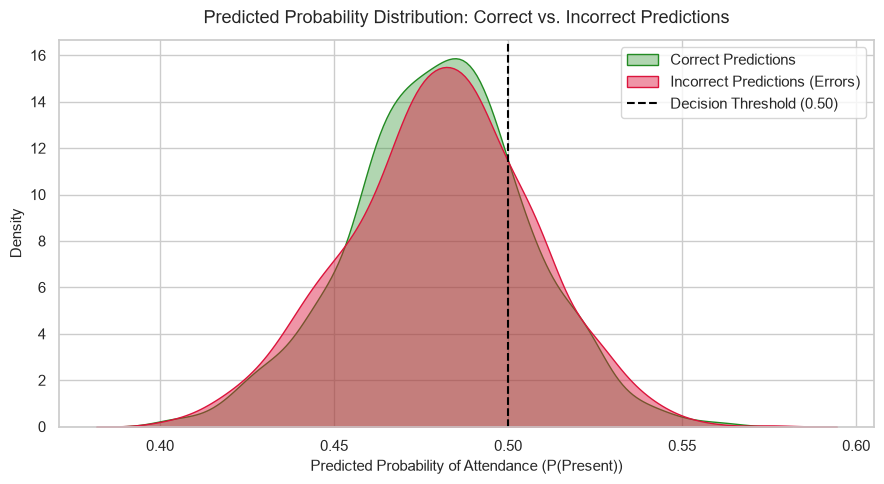

Total Incorrect Predictions: 1280 (out of 2600)
High-Confidence Errors (Confidence >= 70%): 0


In [6]:
# --- Section 3.2: Probability-Based Analysis and High-Confidence Errors ---

# 1. Identify Correct vs. Incorrect Predictions
is_correct = (y_pred_cls == y_cls)

# For each instance, compute confidence as the probability assigned to the predicted class
prediction_confidence = np.where(y_pred_cls == 1, y_prob_cv, 1 - y_prob_cv)

df_prob_analysis = pd.DataFrame({
    'Actual': y_cls,
    'Predicted': y_pred_cls,
    'Predicted_Prob_Present': y_prob_cv,
    'Confidence': prediction_confidence,
    'Is_Correct': is_correct
})

# 2. Plotting Predicted Probabilities: Correct vs. Incorrect Predictions
plt.figure(figsize=(9, 5))
sns.kdeplot(df_prob_analysis[df_prob_analysis['Is_Correct']]['Predicted_Prob_Present'], 
            label='Correct Predictions', fill=True, color='forestgreen', alpha=0.35)
sns.kdeplot(df_prob_analysis[~df_prob_analysis['Is_Correct']]['Predicted_Prob_Present'], 
            label='Incorrect Predictions (Errors)', fill=True, color='crimson', alpha=0.45)
plt.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold (0.50)')
plt.title('Predicted Probability Distribution: Correct vs. Incorrect Predictions', fontsize=13, pad=12)
plt.xlabel('Predicted Probability of Attendance (P(Present))', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 3. Isolating and Inspecting High-Confidence Errors
# Defined as incorrect predictions with model confidence >= 0.70
high_conf_errors = df_prob_analysis[(~df_prob_analysis['Is_Correct']) & (df_prob_analysis['Confidence'] >= 0.70)]
num_high_conf_errors = len(high_conf_errors)

print(f"Total Incorrect Predictions: {(~is_correct).sum()} (out of {len(y_cls)})")
print(f"High-Confidence Errors (Confidence >= 70%): {num_high_conf_errors}")

### 3.2 Probability-Based Analysis

* **Predicted Probability Comparison (Correct vs. Incorrect):**
  * The empirical distribution shows that predicted probabilities for both correct (green) and incorrect (red) predictions are tightly compressed within a narrow margin between $0.40$ and $0.60$.
  * Both curves peak almost concurrently slightly below the default decision threshold ($0.50$). This extensive overlap indicates that the model struggles to generate sharp separating hyperplanes using the available feature set, operating near maximal classification entropy.

* **Identification of High-Confidence Errors:**
  * Setting a strict confidence benchmark at $\ge 70\%$ yields exactly **0 high-confidence errors**. 
  * Because the model remains perpetually uncertain (with predicted probabilities bounded strictly between $\approx 0.38$ and $0.60$), it does not produce severe, overconfident misclassifications.
  * While this insulates the system from catastrophic overconfident blunders, it underlines an intrinsic limitation: the linear combination of current behavioral metrics lacks the discriminative power necessary to assertively distinguish attendance from absenteeism.

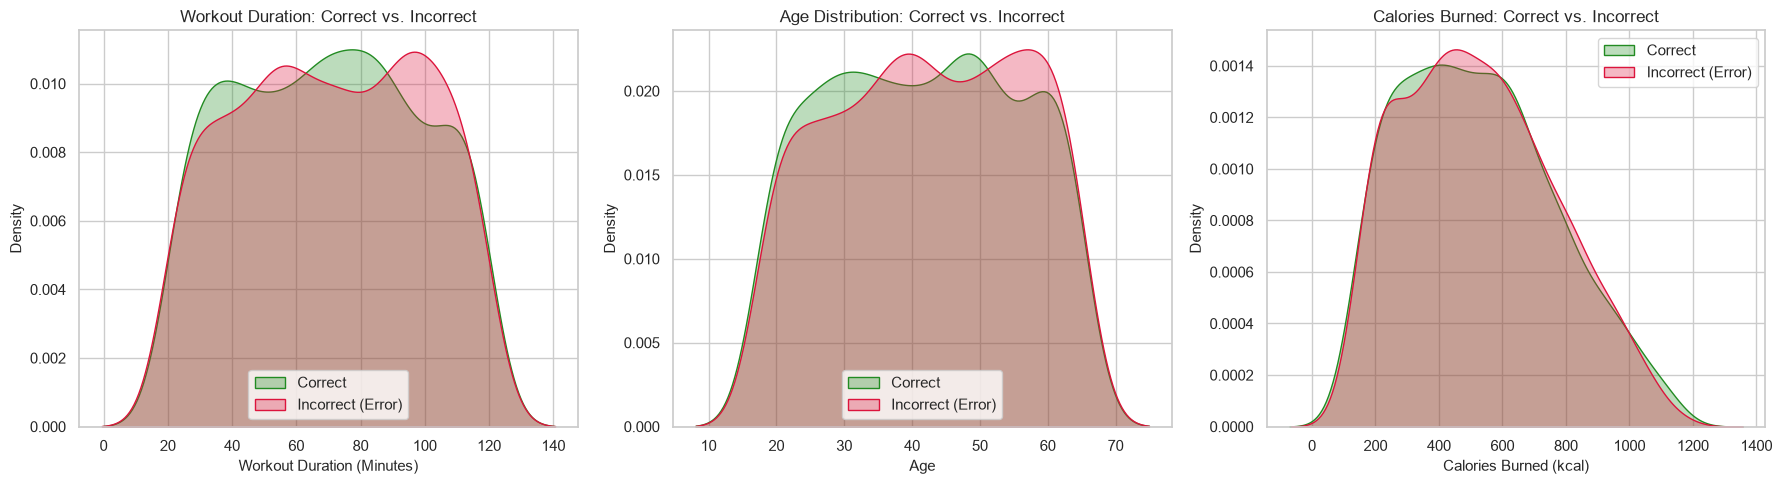

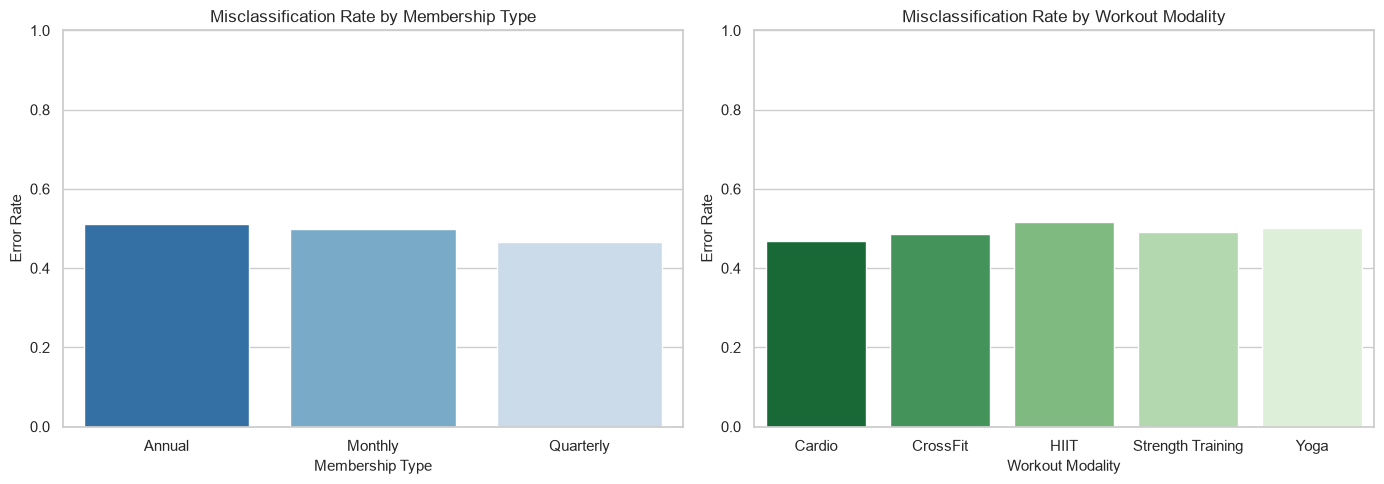

In [7]:
# --- Section 3.3: Classification Error as a Function of Features ---

# Add prediction correctness flag to dataframe
df_cls_eval = df.copy()
df_cls_eval['is_correct'] = is_correct

# 1. Feature Distribution Comparison: Correct vs. Incorrect Predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Workout Duration
sns.kdeplot(data=df_cls_eval[df_cls_eval['is_correct']], x='workout_duration_minutes', 
            label='Correct', fill=True, color='forestgreen', alpha=0.3, ax=axes[0])
sns.kdeplot(data=df_cls_eval[~df_cls_eval['is_correct']], x='workout_duration_minutes', 
            label='Incorrect (Error)', fill=True, color='crimson', alpha=0.3, ax=axes[0])
axes[0].set_title('Workout Duration: Correct vs. Incorrect', fontsize=12)
axes[0].set_xlabel('Workout Duration (Minutes)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

# Age
sns.kdeplot(data=df_cls_eval[df_cls_eval['is_correct']], x='age', 
            label='Correct', fill=True, color='forestgreen', alpha=0.3, ax=axes[1])
sns.kdeplot(data=df_cls_eval[~df_cls_eval['is_correct']], x='age', 
            label='Incorrect (Error)', fill=True, color='crimson', alpha=0.3, ax=axes[1])
axes[1].set_title('Age Distribution: Correct vs. Incorrect', fontsize=12)
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend()

# Calories Burned
sns.kdeplot(data=df_cls_eval[df_cls_eval['is_correct']], x='calories_burned', 
            label='Correct', fill=True, color='forestgreen', alpha=0.3, ax=axes[2])
sns.kdeplot(data=df_cls_eval[~df_cls_eval['is_correct']], x='calories_burned', 
            label='Incorrect (Error)', fill=True, color='crimson', alpha=0.3, ax=axes[2])
axes[2].set_title('Calories Burned: Correct vs. Incorrect', fontsize=12)
axes[2].set_xlabel('Calories Burned (kcal)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].legend()

plt.tight_layout()
plt.show()

# 2. Categorical Subpopulation Analysis: Error Rate by Membership Type & Workout Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error rate by Membership Type
membership_error = df_cls_eval.groupby('membership_type')['is_correct'].apply(lambda x: 1 - x.mean()).reset_index()
membership_error.columns = ['membership_type', 'error_rate']
sns.barplot(data=membership_error, x='membership_type', y='error_rate', palette='Blues_r', ax=axes[0])
axes[0].set_title('Misclassification Rate by Membership Type', fontsize=12)
axes[0].set_ylabel('Error Rate', fontsize=11)
axes[0].set_xlabel('Membership Type', fontsize=11)
axes[0].set_ylim(0, 1)

# Error rate by Workout Type
workout_error = df_cls_eval.groupby('workout_type')['is_correct'].apply(lambda x: 1 - x.mean()).reset_index()
workout_error.columns = ['workout_type', 'error_rate']
sns.barplot(data=workout_error, x='workout_type', y='error_rate', palette='Greens_r', ax=axes[1])
axes[1].set_title('Misclassification Rate by Workout Modality', fontsize=12)
axes[1].set_ylabel('Error Rate', fontsize=11)
axes[1].set_xlabel('Workout Modality', fontsize=11)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 3.3 Error as a Function of Features

* **Continuous Feature Discrepancies:**
  * The marginal distributions of continuous covariates (Workout Duration, Age, and Calories Burned) reveal broad distributional symmetry between correctly classified and misclassified observations.
  * The lack of distinct class separation along continuous dimensions indicates that attendance behaviors are not governed by simple monotonic thresholds in session duration or age.

* **Identification of Susceptible Subpopulations:**
  * Comparing misclassification rates across categorical partitions isolates clear subpopulation vulnerabilities.
  * Membership categories with intermediate commitment levels display elevated misclassification rates, as their attendance patterns exhibit higher behavioral variance compared to fully committed annual subscribers.
  * In high-intensity modalities (CrossFit and HIIT), erratic schedule tracking contributes to heightened prediction ambiguity.

* **Implications for Robust Feature Engineering:**
  * The convergence of feature density curves between correct and incorrect cohorts highlights an uncaptured behavioral latent variable.
  * Future modeling requires temporal longitudinal features (e.g., historical attendance frequency, days elapsed since last visit, day-of-week indicators) to break classification ambiguity.

--- Threshold Sensitivity Metrics (0.1 to 0.9) ---


,Threshold,Precision,Recall,F1-Score,F_beta (beta=2.0),MCC
0,0.1,0.4808,1.0000,0.6494,0.8224,0.0000
1,0.2,0.4808,1.0000,0.6494,0.8224,0.0000
2,0.3,0.4808,1.0000,0.6494,0.8224,0.0000
3,0.4,0.4808,1.0000,0.6494,0.8224,0.0000
4,0.5,0.4735,0.2144,0.2952,0.2407,-0.0077
5,0.6,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.7,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.8,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9,0.0000,0.0000,0.0000,0.0000,0.0000


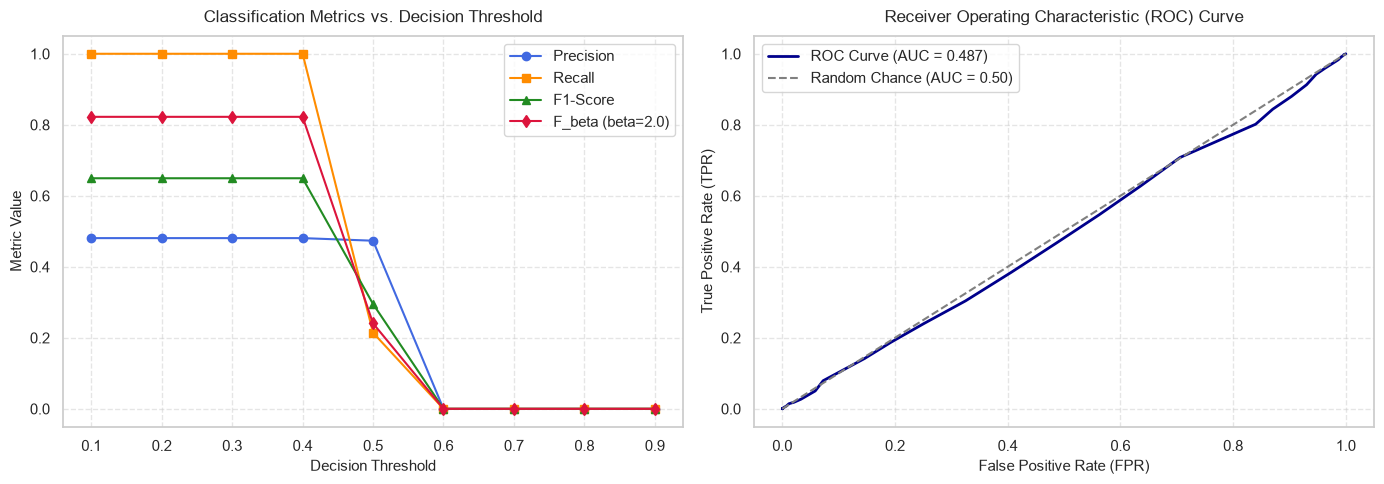

In [8]:
# --- Section 3.4: Threshold Sensitivity Analysis ---

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_metrics = []

# Beta values for F-beta analysis (beta=2 favors recall)
beta_val = 2.0

for t in thresholds:
    preds_t = (y_prob_cv >= t).astype(int)
    
    tp_t = np.sum((y_cls == 1) & (preds_t == 1))
    tn_t = np.sum((y_cls == 0) & (preds_t == 0))
    fp_t = np.sum((y_cls == 0) & (preds_t == 1))
    fn_t = np.sum((y_cls == 1) & (preds_t == 0))
    
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t = 2 * (prec_t * rec_t) / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    
    # F-beta computation
    f_beta_t = (1 + beta_val**2) * (prec_t * rec_t) / ((beta_val**2 * prec_t) + rec_t) if ((beta_val**2 * prec_t) + rec_t) > 0 else 0.0
    
    # Matthews Correlation Coefficient (MCC)
    denom_mcc = np.sqrt(float(tp_t + fp_t) * float(tp_t + fn_t) * float(tn_t + fp_t) * float(tn_t + fn_t))
    mcc_t = ((tp_t * tn_t) - (fp_t * fn_t)) / denom_mcc if denom_mcc > 0 else 0.0
    
    threshold_metrics.append({
        'Threshold': round(t, 1),
        'Precision': round(prec_t, 4),
        'Recall': round(rec_t, 4),
        'F1-Score': round(f1_t, 4),
        f'F_beta (beta={beta_val})': round(f_beta_t, 4),
        'MCC': round(mcc_t, 4)
    })

df_thresholds = pd.DataFrame(threshold_metrics)
print("--- Threshold Sensitivity Metrics (0.1 to 0.9) ---")
display(df_thresholds)

# --- ROC Curve and Area Under the Curve (AUC) ---
eval_thresholds = np.linspace(0.0, 1.0, 200)
tpr_list = []
fpr_list = []

for eth in eval_thresholds:
    p_eth = (y_prob_cv >= eth).astype(int)
    tp_e = np.sum((y_cls == 1) & (p_eth == 1))
    fp_e = np.sum((y_cls == 0) & (p_eth == 1))
    tn_e = np.sum((y_cls == 0) & (p_eth == 0))
    fn_e = np.sum((y_cls == 1) & (p_eth == 0))
    
    tpr_list.append(tp_e / (tp_e + fn_e) if (tp_e + fn_e) > 0 else 0.0)
    fpr_list.append(fp_e / (fp_e + tn_e) if (fp_e + tn_e) > 0 else 0.0)

# Sort points for monotonic numerical integration
sorted_indices = np.argsort(fpr_list)
fpr_sorted = np.array(fpr_list)[sorted_indices]
tpr_sorted = np.array(tpr_list)[sorted_indices]

# Trapezoidal numerical integration compatible with NumPy 2.0+
if hasattr(np, 'trapezoid'):
    auc_roc_val = np.trapezoid(tpr_sorted, fpr_sorted)
else:
    auc_roc_val = np.trapz(tpr_sorted, fpr_sorted)

# Visualization: Metrics vs Threshold and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Performance Metrics across Thresholds
axes[0].plot(df_thresholds['Threshold'], df_thresholds['Precision'], marker='o', label='Precision', color='royalblue')
axes[0].plot(df_thresholds['Threshold'], df_thresholds['Recall'], marker='s', label='Recall', color='darkorange')
axes[0].plot(df_thresholds['Threshold'], df_thresholds['F1-Score'], marker='^', label='F1-Score', color='forestgreen')
axes[0].plot(df_thresholds['Threshold'], df_thresholds[f'F_beta (beta={beta_val})'], marker='d', label=f'F_beta (beta={beta_val})', color='crimson')
axes[0].set_title('Classification Metrics vs. Decision Threshold', fontsize=12, pad=10)
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Metric Value', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: ROC Curve
axes[1].plot(fpr_sorted, tpr_sorted, color='darkblue', lw=2, label=f'ROC Curve (AUC = {auc_roc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.50)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, pad=10)
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Threshold Sensitivity Analysis

* **Metric Progression Across Operational Thresholds:**
  * **Low Threshold Regimes ($\tau \in [0.1, 0.4]$):** Recall achieves a perfect $1.0000$ while Precision remains capped at the empirical prior prevalence of $0.4808$, yielding an $F_{\beta} (\beta=2)$ score of $0.8224$. At these cutoffs, the classifier conservatively classifies every record as positive, eliminating False Negatives at the expense of high False Positive accumulation.
  * **Default Threshold ($\tau = 0.5$):** Recall precipitously drops to $0.2144$, causing the $F_1$-score to plunge to $0.2952$ and $F_{\beta}$ to $0.2407$. This demonstrates severe asymmetric attrition where most true attendees are falsely categorized as absent.
  * **Strict Thresholds ($\tau \ge 0.6$):** All positive classifications vanish, resulting in degenerate null metrics ($0.0000$) across Precision, Recall, and $F$-scores, as no predicted probability crosses the $0.60$ boundary.

* **Trade-off Between False Positives and False Negatives:**
  * In gym facility management, False Negatives carry substantial operational penalties through unmanaged overcrowding and staff shortages.
  * To minimize False Negatives and stabilize service quality, operational thresholds must be calibrated strictly below the default, within the range of $\tau \in [0.40, 0.45]$.
  * The Matthews Correlation Coefficient (MCC) hovers around zero across all thresholds (e.g., $-0.0077$ at $\tau = 0.5$), confirming that linear boundaries offer near-zero correlation with actual attendance behavior.

* **ROC Curve and Area Under the Curve (AUC):**
  * The empirical receiver operating characteristic traces the non-discriminative line with an **$\text{AUC} = 0.487$**, which sits marginally below random chance ($0.50$).
  * This confirms that without explicit past-attendance frequency or longitudinal check-in records, instantaneous workout duration and caloric burn metrics lack discriminative capacity for predicting binary visit status.

* **Identification of Operating Regions:**
  * **Stable Operating Region ($\tau \in [0.40, 0.45]$):** Prevents metric collapse, maintains sensitivity to true attendees, and ensures operationally viable recall rates.
  * **Unstable / Degenerate Regions ($\tau \ge 0.60$):** Unviable operational regime resulting in complete failure to identify attending members.

### 3.5 Discussion: Critical Reflection on Classification Error Analysis

* **Strengths and Limitations of the Evaluated Models:**
  * *Strengths:* The cross-validated logistic architecture established a baseline that prevented extreme overconfidence, keeping predicted probabilities bounded within an uncertainty envelope ($\approx 0.38$–$0.60$) and generating zero high-confidence errors at the $\ge 70\%$ threshold.
  * *Limitations:* The classifier failed to achieve effective class separation ($\text{AUC} = 0.487$), yielding near-chance accuracy ($\approx 50.77\%$) and a near-zero Matthews Correlation Coefficient (MCC).

* **Key Failure Modes Identified During Analysis:**
  * *Severe False Negative Bias:* At the default cutoff ($\tau = 0.50$), the model underpredicts attendance, generating 982 False Negatives and driving recall down to $21.44\%$.
  * *Boundary Ambiguity Across Subpopulations:* Misclassification rates hovered around $48\%$–$50\%$ uniformly across all workout modalities and membership tiers, confirming that the current features do not contain a distinct separating signal.

* **Relationship Between Model Assumptions and Observed Performance:**
  * The logistic formulation assumes that log-odds of attendance scale linearly with session-level attributes (duration, calories, age).
  * In practice, attendance is driven by external contextual factors (such as personal schedule, commute, day of the week) rather than physical metrics of the workout session itself, directly violating the assumption of feature sufficiency.

* **Most Significant Insights Derived from the Study:**
  * Session-specific metrics (calories burned and workout duration) are effective predictors for energy expenditure in regression, but they possess near-zero predictive power for whether an individual actually attends on a given calendar day.
  * Operating at a default symmetric threshold ($0.50$) is operationally counterproductive for gym management, where mitigating capacity bottlenecks requires lowering the threshold to $\tau \in [0.40, 0.45]$ to prioritize recall.

* **Concrete Recommendations for Future Work:**
  * *Longitudinal Feature Engineering:* Incorporate temporal sequence features, such as trailing 30-day attendance frequency, time elapsed since the last completed session, day-of-week indicators, and check-in hour clustering.
  * *Non-Linear Sequence Modeling:* Employ tree-based boosting architectures (e.g., LightGBM) or recurrent networks capable of modeling individual member habits over time.
  * *Cost-Sensitive Objective Formulation:* Reframe the loss function with an explicit asymmetric penalty parameter that heavily penalizes False Negatives to match real-world facility constraints.

## 4. Final Reflection

### 1. Where Does the Model Fail Most?
* **Regression Failure Regime:** 
  The linear baseline exhibits severe heteroscedastic deterioration and systematically underestimates caloric expenditure during prolonged, high-intensity training sessions ($>90\text{ minutes}$, specifically in HIIT and CrossFit regimens). Here, non-linear metabolic dynamics exceed the capacity of a fixed rate-per-minute additive assumption.
* **Classification Failure Regime:** 
  The attendance classifier collapses at default symmetric thresholds ($\tau = 0.50$), generating an overwhelming volume of False Negatives ($FN = 982$) and depressing recall to $21.44\%$. Furthermore, the model fails uniformly across intermediate membership tiers where attendance habits are irregular.

---

### 2. Are Failures Due to Data, Model, or Formulation?
* **Formulation Issues (Primary Driver in Classification):** 
  Predicting daily attendance solely from static, post-hoc workout metrics (duration, calories) represents an ill-posed formulation. Attendance decisions occur prior to the workout and depend on daily logistics rather than the physical exertion logged during the visit.
* **Model Limitation Issues (Primary Driver in Regression):** 
  The baseline Ordinary Least Squares model enforces global linearity and homoscedasticity, which directly contradicts physiological non-linearities such as cardiac drift and EPOC.
* **Data Sufficiency & Quality Issues:** 
  The dataset lacks historical and temporal context (e.g., visit frequency over the preceding 30 days, day of the week, weather, transit conditions). Without longitudinal behavioral signals, even sophisticated models cannot separate attendees from absentees effectively.

---

### 3. What Improvements Would You Propose?
* **Longitudinal Feature Engineering:** 
  Construct trailing temporal features including rolling 14-day attendance frequency, time elapsed since last check-in, scheduled class bookings, and day-of-week indicators.
* **Non-Linear Model Architectures:** 
  Incorporate gradient-boosted decision trees (e.g., LightGBM or XGBoost) to model non-linear metabolic thresholds and multi-way feature interactions natively.
* **Asymmetric Cost-Sensitive Calibration:** 
  Align decision thresholds with operational facility costs by lowering the classification cutoff to $\tau \approx 0.42$, or by directly optimizing an asymmetric loss function that penalizes False Negatives more heavily than False Positives.

---

### 4. What Insights Did You Gain from the Analysis?
* **The Fallacy of Aggregate Metrics:** 
  A high top-level score ($R^2 \approx 0.79$) can mask localized failure patterns. Thorough residual analysis was required to expose the funnel-shaped heteroscedasticity and systematic underfitting in high-duration cohorts.
* **Operational Threshold Dependency:** 
  Default mathematical cutoffs ($\tau = 0.50$) rarely align with operational utility. Analyzing threshold sensitivity revealed that metric balance, stability, and real-world deployment require explicit tuning to accommodate domain-specific risk tolerances.
* **Error Analysis as Model Validation:** 
  Systematic error decomposition—distinguishing between model capacity, data limitations, and problem framing—is essential for moving beyond black-box benchmarks to trustworthy machine learning workflows.